In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import brentq
from scipy.optimize import minimize

This code is trying to check whether certain pairs of parameters can produce a bound state, and then, for each physical pair, compute the binding energy.

# Constants

In [ ]:
hbar_c = 197.327   # MeV*fm
mu_c2 = 469.5      # MeV

# Functions

### Bound State Condition

$$
V_0 L^2 \geq \frac{\pi^2 \hbar^2 c^2}{8 \mu c^2}
$$

In [ ]:
def find_valid_pairs(V_list, L_list):
    
    threshold = (np.pi**2 * (hbar_c**2)) / (8 * mu_c2)
    valid_pairs = []

    for V0, L in zip(V_list, L_list):
        v0_L2 = V0 * (L**2)

        if v0_L2 >= threshold:
            valid_pairs.append((V0, L, v0_L2))
    
    df = pd.DataFrame(valid_pairs, columns=["V0", "L", "V0*L^2"])

    return df

### Solve equation

We want to solve the equation:

$$
-\xi \cot(\xi) = \sqrt{C - \xi^2}
$$

where:

$$
C = \frac{2 \mu c^2 V_0 L^2}{(\hbar c)^2}
$$


### What the function does

The function `solve_bound_state_xi(v0_L2)` takes as input the quantity:

$$
V_0 L^2
$$

and calculates the dimensionless parameter:

$$
C = \frac{2 \mu c^2 V_0 L^2}{(\hbar c)^2}
$$

Then, it checks whether the value of \(C\) is large enough for a bound state to exist.

The condition used is:

$$
-\xi \cot(\xi) = \sqrt{C-\xi^2}
$$

$$
\frac{\pi}{2} < \xi < \pi
$$

$$
\sqrt{C-\xi^2} \in \mathbb{R}
$$

$$
C-\xi^2 \geq 0
$$

$$
C \geq \xi^2
$$

$$
\xi_{\min} = \frac{\pi}{2}
$$

$$
C \geq \left(\frac{\pi}{2}\right)^2
$$

$$
C \geq \frac{\pi^2}{4}
$$
----
The original equation is:

$$
-\xi \cot(\xi) = \sqrt{C - \xi^2}
$$

To solve it numerically, we rewrite it as:

$$
-\xi \cot(\xi) - \sqrt{C - \xi^2} = 0
$$

So we define the function:

$$
f(\xi) = -\xi \cot(\xi) - \sqrt{C - \xi^2}
$$

Since:

$$
\cot(\xi) = \frac{\cos(\xi)}{\sin(\xi)}
$$

this is equivalent to:

$$
f(\xi) = -\xi \frac{\cos(\xi)}{\sin(\xi)} - \sqrt{C - \xi^2}
$$

The solution is found when:

$$
f(\xi) = 0
$$

---

### Search interval

The solution is searched in the interval:

$$
\frac{\pi}{2} < \xi < \pi
$$

but we also need:

$$
\xi < \sqrt{C}
$$

because the square root:

$$
\sqrt{C - \xi^2}
$$

must be real.

In [ ]:
def solve_bound_state_xi(v0_L2):

    C = 2.0 * mu_c2 * v0_L2 / (hbar_c**2)

    if C < (np.pi**2 / 4):
        return None

    def f_xi(xi):
        if xi >= np.sqrt(C):
            return np.nan
        return -xi * np.cos(xi)/np.sin(xi) - np.sqrt(C - xi**2)

    eps = 1e-6
    a = np.pi/2 + eps
    b = min(np.pi - eps, np.sqrt(C) - eps)

    if b <= a:
        return None

    try:
        return brentq(f_xi, a, b)
    except:
        return None


### Energy Bound Calculation

Compute the theoretical binding energy E_B for a given pair (V0, L).

$E_B = V_0 - \frac{\hbar^2 \xi^2}{2\mu L^2}$

In [ ]:
def compute_binding_energy(V0, L):

    v0_L2 = V0 * (L**2)
    xi = solve_bound_state_xi(v0_L2)

    if xi is None:
        return None

    factor = (hbar_c**2) / (2.0 * mu_c2)
    E_B = V0 - factor * (xi**2 / L**2)

    if E_B <= 0:
        return None

    return E_B

### Plot V(ξ)

In [ ]:
def plot_nu_xi(V0, L):
    """
    Plot the two functions:
        nu = -xi cot(xi)
        nu = sqrt(C - xi^2)
    for a given pair (V0, L).
    """
    v0_L2 = V0 * L**2
    C = 2.0 * mu_c2 * v0_L2 / (hbar_c**2)

    if C <= np.pi**2 / 4:
        print("This pair does not support a bound state.")
        return

    xi_max = min(np.pi - 1e-3, np.sqrt(C) - 1e-3)
    xi_vals = np.linspace(np.pi/2 + 1e-3, xi_max, 500)

    y1 = -xi_vals * np.cos(xi_vals) / np.sin(xi_vals)
    y2 = np.sqrt(C - xi_vals**2)

    plt.figure(figsize=(8,5))
    plt.plot(xi_vals, y1, label=r"$-\xi \cot\xi$")
    plt.plot(xi_vals, y2, label=r"$\sqrt{C-\xi^2}$")

    # optional: mark the root if it exists
    xi_root = solve_bound_state_xi(v0_L2)
    if xi_root is not None:
        nu_root = np.sqrt(C - xi_root**2)
        plt.scatter([xi_root], [nu_root], marker="o", label=fr"root = {xi_root:.4f}")

    plt.xlabel(r"$\xi$")
    plt.ylabel(r"$\nu$")
    plt.title(f"Graphical solution for V0={V0:.3f} MeV, L={L:.3f} fm")
    plt.grid(True)
    plt.legend()
    plt.show()

### u(r) - Reduced radial wavefunction of the deuteron

$$
u(r) =
\begin{cases}
A \sin(kr), & r \leq L \\[6pt]
B e^{-\gamma r}, & r > L
\end{cases}
$$

In [ ]:
def u_r(r):
    r = np.array(r)
    u = np.zeros_like(r)

    inside = (r <= L)
    outside = (r > L)

    u[inside] = A * np.sin(k * r[inside])
    u[outside] = B * np.exp(-gamma * r[outside])

    return u

### R(r) - Radial wavefunction

$$
R(r) = \frac{u(r)}{r}
$$


$$
R(r) =
\begin{cases}
Ak, & r = 0 \\[6pt]
\dfrac{A\sin(kr)}{r}, & 0 < r \leq L \\[10pt]
\dfrac{B e^{-\gamma r}}{r}, & r > L
\end{cases}
$$

In [ ]:
def R_r(r):
    r = np.array(r)
    u = u_r(r)

    R = np.zeros_like(r)

    zero_mask = np.isclose(r, 0.0)
    nonzero_mask = ~zero_mask

    # όριο στο r=0
    R[zero_mask] = A * k
    R[nonzero_mask] = u[nonzero_mask] / r[nonzero_mask]

    return R

# PART A: Choose V,L Pairs

### First Method: 1000 Random Pairs

In [ ]:
N = 1000 
E_bound_real = 2.22463
V0_Random = np.random.uniform(5, 100, N) # MeV
L_Random = np.random.uniform(0.5, 5, N) # fm
Random_Pairs = find_valid_pairs(V0_Random, L_Random)
Random_Pairs["xi"] = Random_Pairs.apply(lambda row: solve_bound_state_xi(row["V0"]*row["L"]**2), axis=1)
Random_Pairs = Random_Pairs.dropna(subset=["xi"])
E_bound_ran = Random_Pairs["V0"] - (hbar_c**2 * Random_Pairs["xi"]**2) / (2 * mu_c2 * Random_Pairs["L"]**2)
Random_Pairs["E_bound"] = E_bound_ran
Random_Pairs["error"] = abs(Random_Pairs["E_bound"] - E_bound_real)
best_df = Random_Pairs.sort_values("error")
best_pair = best_df.iloc[0]
print(best_pair)


V0          24.825019
L            2.562780
V0*L^2     163.046779
xi           1.885514
E_bound      2.378736
error        0.154106
Name: 606, dtype: float64


/var/folders/jh/_1_291f9051b6k5b1q1clbrr0000gn/T/ipykernel_18000/468427598.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plot_nu_xi(best_pair[0], best_pair[1])


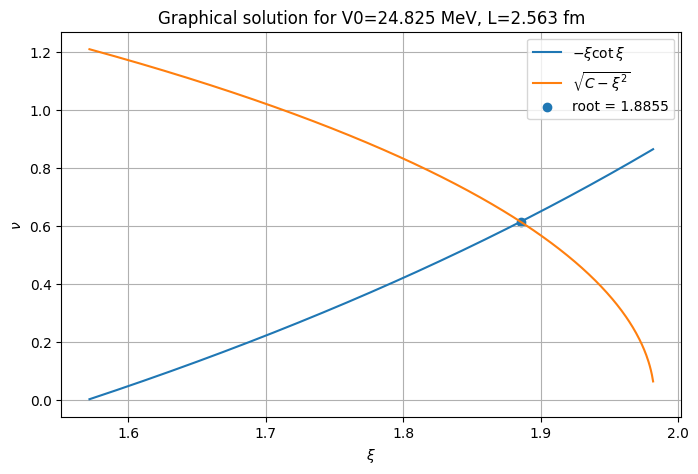

In [ ]:
plot_nu_xi(best_pair[0], best_pair[1])

### Second Method: Optimal Pair

### Loss function

The experimental binding energy of the deuteron is:

$$
E_{B,\text{real}} = 2.22463 \ \text{MeV}
$$

The parameters that we want to optimize are:

$$
\mathbf{p} = (V_0, L)
$$

The loss function is defined as:

$$
\mathcal{L}(V_0,L)
=
\left[
E_B(V_0,L) - E_{B,\text{real}}
\right]^2
$$

The physical constraints are:

$$
V_0 > 0
$$

$$
L > 0
$$

If these constraints are not satisfied, a large penalty is assigned:

$$
\mathcal{L}(V_0,L) = 10^9
$$

If no bound state exists for the chosen parameters, another penalty is assigned:

$$
\mathcal{L}(V_0,L) = 10^8
$$

In [ ]:
# Loss Function
E_bound_real = 2.22463

def loss_function(params):
    """
    Loss function for optimization.
    params = [V0, L]
    """
    V0, L = params

    # physically allowed positive parameters
    if V0 <= 0 or L <= 0:
        return 1e9

    E_B = compute_binding_energy(V0, L)

    # penalty if no bound state
    if E_B is None:
        return 1e8

    return (E_B - E_bound_real)**2

In [ ]:
initial_guess = [35.0, 2.0]

print("Initial guess:", initial_guess)
print("E_B =", compute_binding_energy(initial_guess[0], initial_guess[1]))
print("Loss =", loss_function(initial_guess))

Initial guess: [35.0, 2.0]
E_B = 1.691859317100942
Loss = 0.28384460055672855


In [ ]:
result = minimize(
    loss_function,
    x0=initial_guess,
    method="L-BFGS-B",
    bounds=((1.0, 150.0), (0.2, 8.0))
)

In [ ]:
V0_best, L_best = result.x
E_best = compute_binding_energy(V0_best, L_best)

print("===== OPTIMIZATION RESULT =====")
print("Success    :", result.success)
print("Message    :", result.message)
print(f"V0_best    = {V0_best:.6f} MeV")
print(f"L_best     = {L_best:.6f} fm")
print(f"E_best     = {E_best:.6f} MeV")
print(f"E_exp      = {E_bound_real:.6f} MeV")
print(f"Final loss = {result.fun:.8e}")

===== OPTIMIZATION RESULT =====
Success    : True
Message    : CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
V0_best    = 35.002990 MeV
L_best     = 2.053417 fm
E_best     = 2.224630 MeV
E_exp      = 2.224630 MeV
Final loss = 2.92066983e-15


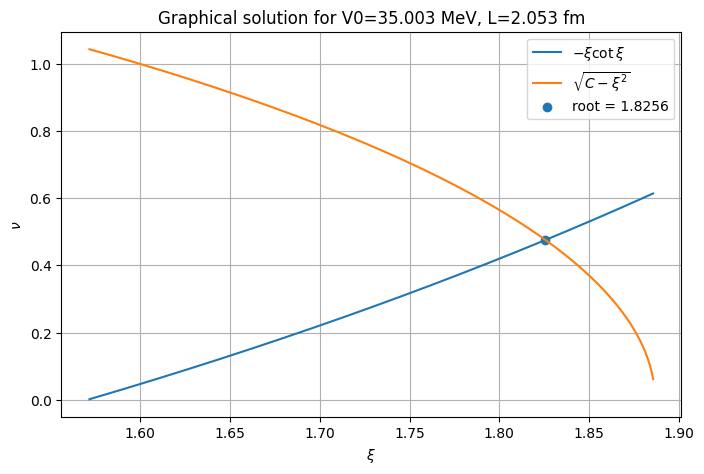

In [ ]:
plot_nu_xi(V0_best, L_best)

# R(r) and u(r) waveform

$$
k = \frac{\xi}{L}
$$

$$
\gamma =
\sqrt{
\frac{
2\mu c^2
\left[
V_0 -
\frac{(\hbar c)^2}{2\mu c^2}
\frac{\xi^2}{L^2}
\right]
}{
(\hbar c)^2
}
}
$$

In [ ]:
V0 = V0_best
L = L_best
xi = solve_bound_state_xi(V0 * L**2)
k = xi / L
gamma = np.sqrt((2 * mu_c2 * (V0 - (hbar_c**2)/(2*mu_c2)*(xi**2/L**2))) / (hbar_c**2))

### Normalization of the reduced radial wavefunction

The reduced radial wavefunction is normalized as:

$$
\int_0^\infty |u(r)|^2 \, dr = 1
$$

with:

$$
u(r) =
\begin{cases}
A\sin(kr), & r \leq L \\[6pt]
B e^{-\gamma r}, & r > L
\end{cases}
$$

Therefore:

$$
\int_0^L A^2\sin^2(kr)\,dr
+
\int_L^\infty B^2 e^{-2\gamma r}\,dr
= 1
$$

From the continuity condition at \(r=L\):

$$
A\sin(kL) = B e^{-\gamma L}
$$

so:

$$
B = A\sin(kL)e^{\gamma L}
$$

Substituting into the normalization condition:

$$
A^2
\left[
\int_0^L \sin^2(kr)\,dr
+
\sin^2(kL)
\int_L^\infty e^{-2\gamma(r-L)}\,dr
\right]
=1
$$

The first integral is:

$$
\int_0^L \sin^2(kr)\,dr
=
\frac{L}{2}
-
\frac{\sin(2kL)}{4k}
$$

The second integral is:

$$
\int_L^\infty e^{-2\gamma(r-L)}\,dr
=
\frac{1}{2\gamma}
$$

Thus:

$$
A^2
\left[
\frac{L}{2}
-
\frac{\sin(2kL)}{4k}
+
\frac{\sin^2(kL)}{2\gamma}
\right]
=1
$$

So the normalization constant \(A\) is:

$$
A =
\frac{1}
{\sqrt{
\frac{L}{2}
-
\frac{\sin(2kL)}{4k}
+
\frac{\sin^2(kL)}{2\gamma}
}}
$$

and:

$$
B = A\sin(kL)e^{\gamma L}
$$

In [ ]:
term1 = L / 2.0
term2 = np.sin(2 * k * L) / (4 * k)
term3 = (np.sin(k * L)**2) / (2 * gamma)

A = 1.0 / np.sqrt(term1 - term2 + term3)
B = A * np.sin(k * L) * np.exp(gamma * L)

print("A =", A)
print("B =", B)

A = 0.5602947671833773
B = 0.8723947854076249


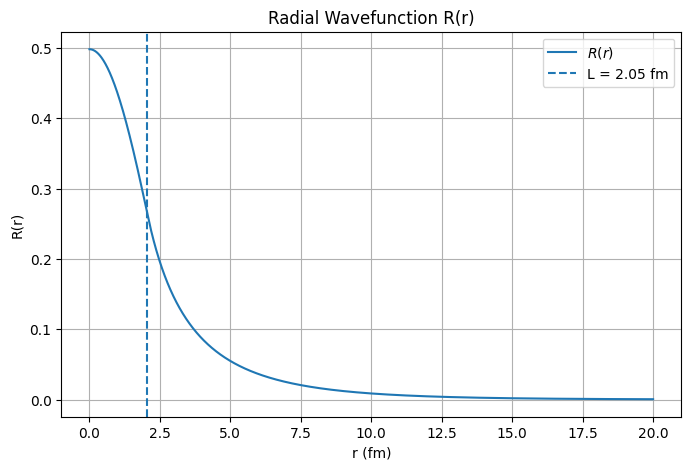

In [ ]:
r_vals = np.linspace(0, 20, 2000)

u_vals = u_r(r_vals)
R_vals = R_r(r_vals)

plt.figure(figsize=(8,5))
plt.plot(r_vals, R_vals, label=r"$R(r)$")
plt.axvline(L, linestyle="--", label=f"L = {L:.2f} fm")

plt.xlabel("r (fm)")
plt.ylabel("R(r)")
plt.title("Radial Wavefunction R(r)")
plt.legend()
plt.grid()
plt.show()

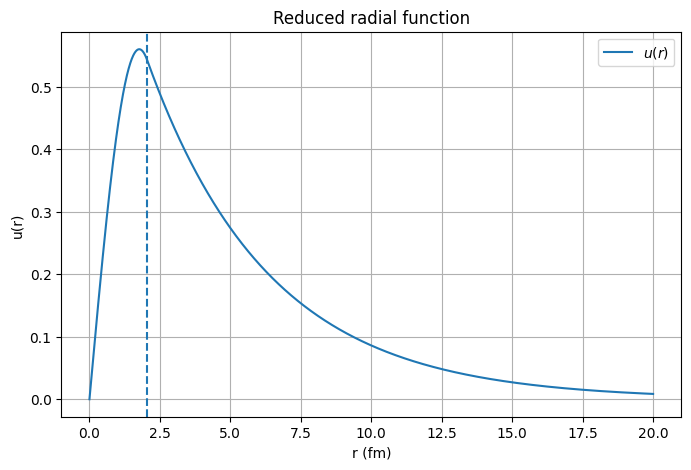

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(r_vals, u_vals, label=r"$u(r)$")
plt.axvline(L, linestyle="--")

plt.xlabel("r (fm)")
plt.ylabel("u(r)")
plt.title("Reduced radial function")
plt.grid()
plt.legend()
plt.show()

The plot shows the radial wavefunction $R(r)$ and $u(r)$ of the deuteron as a function of the radial distance $r$.

The vertical dashed line corresponds to the range of the nuclear potential:

$$
L = 2.05 \ \text{fm}
$$

For $r \leq L $, the proton and neutron are inside the attractive nuclear potential well. In this region, the reduced radial wavefunction has an oscillatory form:

$$
u(r) = A\sin(kr)
$$

and therefore:

$$
R(r) = \frac{A\sin(kr)}{r}
$$

At \(r=0\), the radial wavefunction remains finite because:

$$
R(0) = \lim_{r\to 0}\frac{A\sin(kr)}{r} = Ak
$$

This is why the curve does not diverge at the origin.

For \(r > L\), the particle is outside the range of the nuclear force. Since the deuteron is a bound state, the wavefunction does not become zero immediately, but decreases exponentially:

$$
u(r) = Be^{-\gamma r}
$$

and:

$$
R(r) = \frac{Be^{-\gamma r}}{r}
$$

The exponential tail outside the potential well is physically important. It shows that there is still a non-zero probability of finding the proton and neutron separated by a distance larger than the range of the nuclear force.

# Radius of the Deuteron

With the wavefunction normalized (from `A`, `B` above, $\int_0^\infty |u(r)|^2\,dr = 1$), the mean-square proton&ndash;neutron separation is
$$\langle r^2\rangle = \int_0^\infty r^2\,|u(r)|^2\,dr,$$
since for $l=0$ the radial probability density is $|u(r)|^2\,dr$ (i.e. $|R(r)|^2 r^2\,dr$ with $R(r)=u(r)/r$). This gives the rms separation $r_{\rm rms}=\sqrt{\langle r^2\rangle}$ between the proton and neutron.

The quantity usually quoted as "the radius of the deuteron" is the rms distance of each nucleon **from the center of mass**, not the p&ndash;n separation itself. Since the proton and neutron have (almost) equal mass, each sits a distance $r/2$ from the CM, so the deuteron's rms matter radius is
$$r_d = \frac{r_{\rm rms}}{2}.$$
This is the number that should be compared to the experimental value, $r_d \approx 1.96\ \text{fm}$ (from electron scattering).

In [ ]:
from scipy.integrate import quad

# u_r is already defined and vectorized above; wrap it for scalar quadrature
def u_scalar(r):
    return u_r(np.array([r]))[0]

# Normalization check: with A, B fixed as above, ∫|u(r)|^2 dr should already equal 1
norm_check, _ = quad(lambda r: u_scalar(r)**2, 0, 50, limit=200)

# <r^2> = ∫ r^2 |u(r)|^2 dr  (radial probability density for l=0 is |u(r)|^2 dr)
r2_integral, _ = quad(lambda r: r**2 * u_scalar(r)**2, 0, 50, limit=200)

r_rms = np.sqrt(r2_integral / norm_check)   # rms proton-neutron separation
r_deuteron = r_rms / 2                       # rms matter radius (each nucleon sits r/2 from the CM)

print(f"Normalization check: ∫u(r)^2 dr = {norm_check:.8f}  (should be ≈ 1)")
print(f"<r^2> =           = {r2_integral:.4f} fm^2")
print(f"r_rms (p-n separation)          = {r_rms:.4f} fm")
print(f"Deuteron rms radius (r_rms/2)   = {r_deuteron:.4f} fm")
print(f"Experimental deuteron rms matter radius ≈ 1.96 fm")


Normalization check: ∫u(r)^2 dr = 1.00000000  (should be ≈ 1)
<r^2> = ∫ r^2 u(r)^2 dr          = 15.0020 fm^2
r_rms (p-n separation)          = 3.8732 fm
Deuteron rms radius (r_rms/2)   = 1.9366 fm
Experimental deuteron rms matter radius ≈ 1.96 fm


The computed deuteron rms radius, $r_d \approx 1.94$ fm, is within about 1% of the experimental value ($\approx 1.96$ fm)